In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',as_frame=False)

In [2]:
X,y = mnist.data , mnist.target

In [3]:
X.shape

(70000, 784)

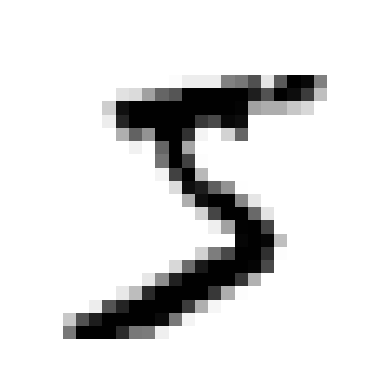

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image,cmap="binary")
    plt.axis("off")

digit = X[0]
plot_digit(digit)
plt.show()

In [5]:
y[0]

'5'

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [7]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [9]:
sgd_clf.predict([digit])

array([ True])

In [10]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [11]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train,y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [12]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [13]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5,y_train_pred)

cm

array([[53892,   687],
       [ 1891,  3530]])

In [15]:
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [16]:
from sklearn.metrics import precision_score, recall_score , f1_score

precision = precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)
print(precision)
recall = recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)
print(recall)
f1score = f1_score(y_train_5,y_train_pred)
print(f1score)

0.8370879772350012
0.6511713705958311
0.7325171197343847


In [19]:
y_score = sgd_clf.decision_function([digit])
y_score

array([2164.22030239])

In [20]:
y_score = sgd_clf.decision_function([X[1]])
y_score

array([-5897.37359354])

In [21]:
threshold = 3000
y_some_digit_pred = (y_score > threshold)
y_some_digit_pred


array([False])

In [22]:
y_score = cross_val_predict(sgd_clf, X_train , y_train_5 , cv=3, method="decision_function")

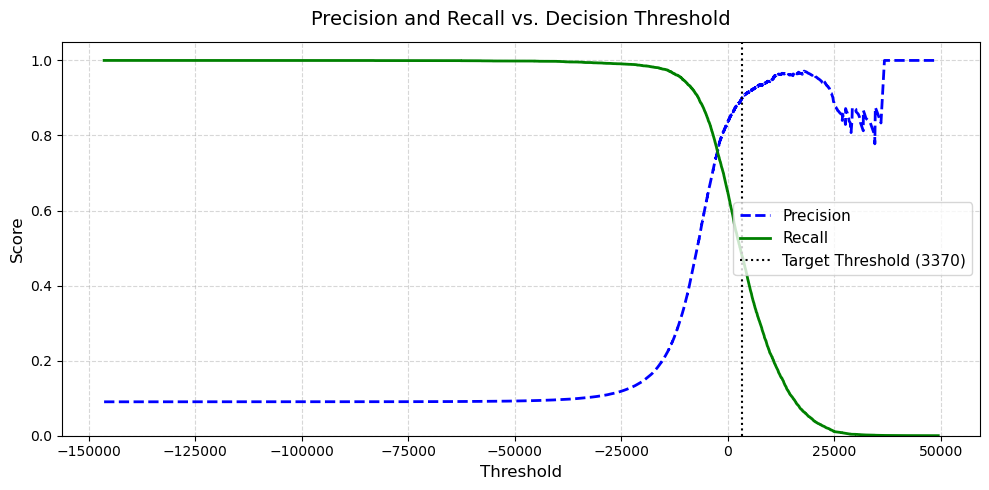

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

# 1. Obtain raw decision scores for ALL 60,000 training images
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)

# 2. Calculate precisions, recalls, and decision thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# 3. Select a specific threshold to highlight (e.g., threshold for 90% precision)
idx_90_precision = (precisions >= 0.90).argmax()
threshold_90 = thresholds[idx_90_precision]

# 4. Plot the Curves
plt.figure(figsize=(10, 5))

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)

# Draw a single vertical line at your target threshold
plt.axvline(
    x=threshold_90, 
    color="k", 
    linestyle=":", 
    label=f"Target Threshold ({threshold_90:.0f})"
)

# Chart Formatting
plt.title("Precision and Recall vs. Decision Threshold", fontsize=14, pad=12)
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim([0, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="center right", fontsize=11)

plt.tight_layout()
plt.show()

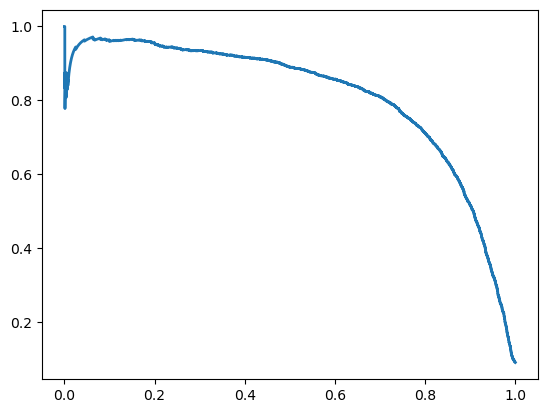

In [24]:
plt.plot(recalls, precisions , linewidth=2 , label="Precision/Recall curve")

In [25]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [26]:
y_train_pred_90 = (y_score >= threshold_for_90_precision)
pre= precision_score(y_train_5,y_train_pred_90)
recall_at_90_precision = recall_score(y_train_5,y_train_pred_90)
print(pre)
print(recall_at_90_precision)

0.9000345901072293
0.4799852425751706


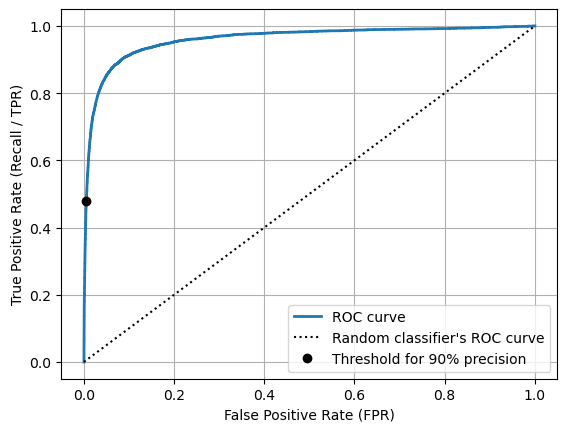

In [27]:
from sklearn.metrics import roc_curve

# 1. Calculate FPR, TPR, and thresholds across all training scores
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

# 2. Find TPR and FPR corresponding to your 90% precision threshold
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

# 3. Plot the curves
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall / TPR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()  # <-- Don't forget the () here!

In [30]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf , X_train ,  y_train_5 , cv=3 , method="predict_proba")
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

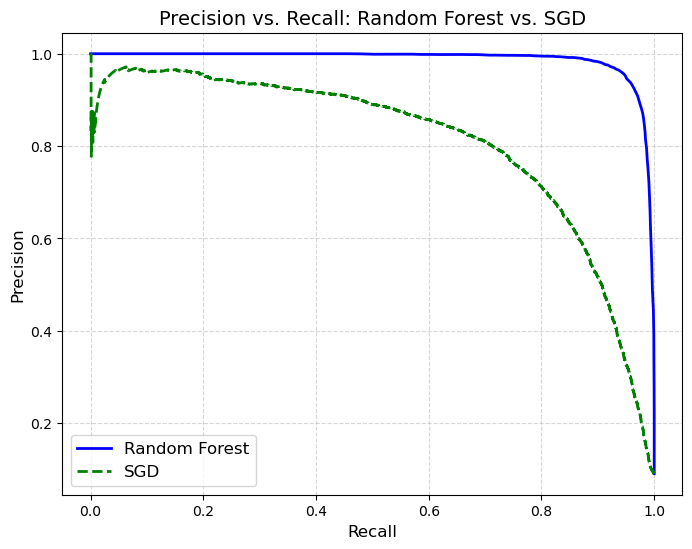

In [31]:
y_scores_forest = y_probas_forest[:, 1]

# 2. Calculate precision and recall for Random Forest
precision_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest
)

# 3. Plot both curves
plt.figure(figsize=(8, 6))
plt.plot(recalls_forest, precision_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "g--", linewidth=2, label="SGD")  # Fixed 'precisions'

# 4. Add labels, grid, and legend
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=12)
plt.title("Precision vs. Recall: Random Forest vs. SGD", fontsize=14)

plt.show()

In [32]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5
f1_score(y_train_5,y_train_pred_forest)

0.9274509803921569

In [33]:
roc_auc_score(y_train_5,y_scores_forest)

NameError: name 'roc_auc_score' is not defined